In [1]:
#Transposing Data

import pandas as pd

df = pd.read_csv('c:/data/RNA_seq_1.csv', sep =',')

df.set_index("attrib_name", inplace=True)

df_transposed = df.T

print(df_transposed.shape)
df_transposed.head()

(528, 4571)


attrib_name,AACS,FSTL1,ELMO2,CREB3L1,RPS11,PNMA1,MMP2,SAMD4A,SMARCD3,A4GNT,...,CNTD2,OCLM,ZSCAN18,MYL4,SLC17A1,TAF5L,L3MBTL,TSTA3,CCDC59,RAC1
TCGA.02.0001,6.5006,8.7297,5.5114,4.8830,10.9848,7.5352,8.6740,5.0326,4.7110,5.1085,...,5.3734,4.0452,5.9452,5.2649,3.7023,6.2648,4.2333,8.1816,7.1473,11.7460
TCGA.02.0003,6.5392,9.7944,6.2140,4.8363,10.8112,6.9979,9.3486,5.0270,5.3277,4.3486,...,5.1081,4.0367,6.4729,4.9223,3.5371,6.3724,4.2408,7.4861,8.2772,11.4917
TCGA.02.0004,7.3778,12.0596,7.0517,6.1124,10.4364,9.1321,11.2485,5.5591,8.2682,4.0524,...,4.6046,3.8521,7.2389,5.3657,3.6313,6.3536,4.0206,7.5645,8.4564,12.2318
TCGA.02.0007,7.1869,4.9451,5.2304,5.8186,10.4773,8.3561,4.4295,5.1759,4.4405,4.8242,...,5.3337,4.5189,5.7233,5.6326,3.9954,5.9280,4.3378,8.1142,8.9638,11.1089
TCGA.02.0009,7.6750,10.8401,6.6207,5.3332,10.6373,6.9429,9.4522,5.1649,4.9522,4.2046,...,5.2383,3.9431,5.9389,5.3012,3.6754,6.2691,4.2926,7.5337,8.1234,11.8188


In [2]:
#Remove Low Variance Genes

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.5)
X_var = selector.fit_transform(df_transposed)

print(X_var.shape)

(528, 1236)


In [3]:
#Standardize

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var)

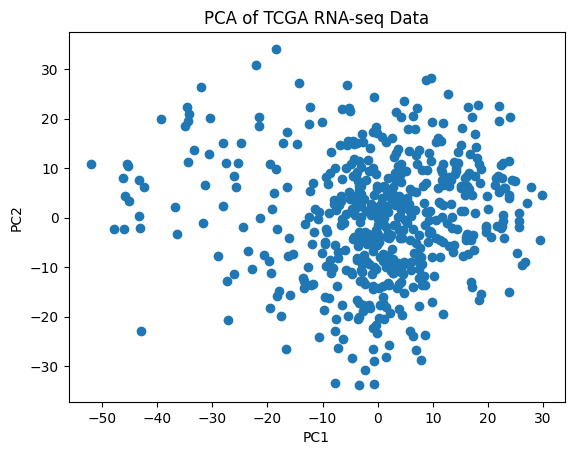

In [4]:
#PCA (Dimensionality Reduction)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA of TCGA RNA-seq Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

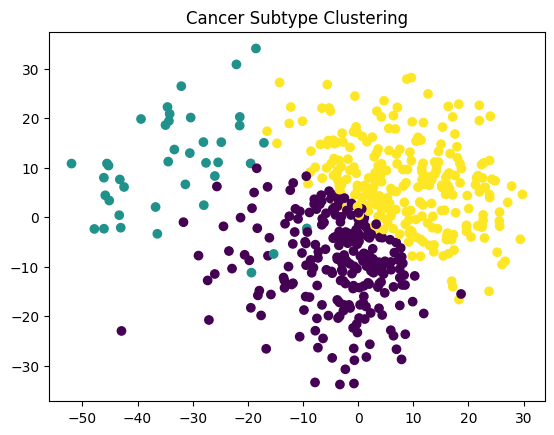

In [5]:
#K-Means Clustering (Subtype Discovery)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Cancer Subtype Clustering")
plt.show()

In [6]:
#Identify Top Genes Driving Variance

import numpy as np

variances = df_transposed.var()
top_genes = variances.sort_values(ascending=False).head(20)

print("Top Variable Genes:")
print(top_genes)

#These highly variable genes may represent potential biomarkers contributing to tumor heterogeneity.

Top Variable Genes:
attrib_name
RPS4Y1     9.709865
TMSL8      6.055377
TF         4.901489
DCX        4.893142
AGXT2L1    4.859432
AQP1       4.504075
KCNJ16     4.193393
CHI3L2     4.164234
PTX3       3.933915
APOD       3.922949
COL11A1    3.906496
TAC1       3.819370
COL3A1     3.678000
MBP        3.557734
FCGBP      3.545713
LUM        3.527354
VSNL1      3.403460
EGFR       3.395831
NEFL       3.362559
PI3        3.338237
dtype: float64


In [1]:
pwd

'C:\\Users\\Gunashree'